### Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Importing the dataset

In [2]:
data = pd.read_csv('shopping_Custmer_Data.csv')

In [3]:
X = data.iloc[:, [3, 4] ]

In [4]:
X

,Annual Income,Spending Score
0,151479,89
1,185088,95
2,70912,76
3,55460,57
4,153752,76
...,...,...
15074,97723,30
15075,73361,74
15076,112337,48
15077,94312,5


### Apply Feature Scaling

In [5]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

In [6]:
X

array([[ 0.79881267,  1.33705873],
       [ 1.44207552,  1.54592857],
       [-0.74320756,  0.88450743],
       ...,
       [ 0.04965041, -0.09021845],
       [-0.2953409 , -1.58711891],
       [-0.60668478, -1.69155383]])

### Construct Dendrogram

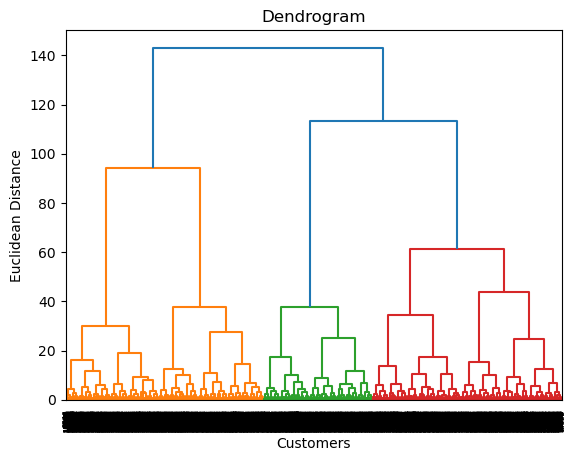

In [8]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.title('Dendrogram')
plt.show()

### Train the model on Hierarchy Clustering

In [32]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 4, metric = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(X)

In [33]:
print(y_hc[:100])

[3 3 1 1 3 2 2 0 0 0 3 1 0 3 1 1 3 1 0 0 2 2 0 0 2 3 0 0 3 0 2 3 0 3 0 3 1
 1 0 0 0 1 1 0 2 1 1 0 2 0 2 0 0 3 0 0 2 0 0 3 0 1 2 0 1 0 1 3 0 2 0 2 3 0
 1 3 0 2 0 0 0 1 3 0 2 0 0 2 0 0 2 2 2 1 0 2 1 3 0 0]


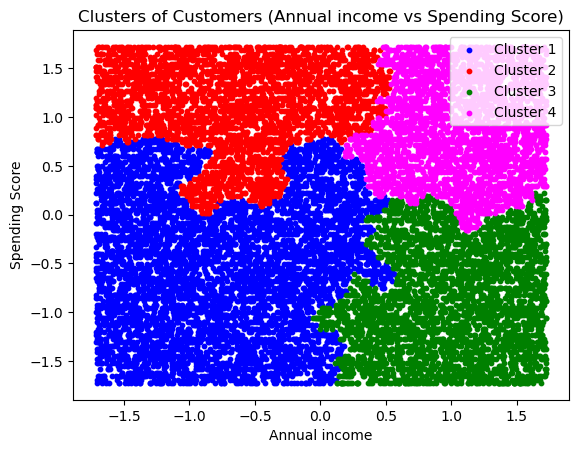

In [34]:
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], c = 'blue', s = 10, label = 'Cluster 1' )
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], c = 'red', s = 10, label = 'Cluster 2' )
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], c = 'green', s = 10, label = 'Cluster 3' )
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], c = 'magenta', s = 10, label = 'Cluster 4' )

plt.title('Clusters of Customers (Annual income vs Spending Score)')
plt.xlabel('Annual income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [36]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

print("Silhouette Score:", silhouette_score(X, y_hc))
print("Davies-Bouldin Index:", davies_bouldin_score(X, y_hc))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X, y_hc))

Silhouette Score: 0.34606864356534267
Davies-Bouldin Index: 0.8484549267776571
Calinski-Harabasz Score: 11714.804158435038
